In [306]:
import arviz.preview as az
import jax
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import xarray as xr
from xarray import open_datatree

jax.config.update("jax_enable_x64", True)

In [307]:
NUM_POPS = 5


## RDM

In [308]:
dt_dict_rdm_approx = {}

for i in range(NUM_POPS):
    dt_path = f"../outputs/rdm/model.num_bins=12/model.num_mid=128/optimizer=adam_cosine_decay/train_steps=500000/hierarchical_recovery_pop{i}_approx.nc"
    dt_dict_rdm_approx[i] = open_datatree(dt_path)

dt_dict_rdm_ref = {}

for i in range(NUM_POPS):
    dt_path = f"../outputs/rdm/model.num_bins=12/model.num_mid=128/optimizer=adam_cosine_decay/train_steps=500000/hierarchical_recovery_pop{i}_ref.nc"
    dt_dict_rdm_ref[i] = open_datatree(dt_path)


In [309]:
pop_coord = xr.DataArray(np.arange(NUM_POPS), dims="pop")                                                                                                                                       
                                                                                                                                                                                              
def merge_datatrees(dt_dict):
    # Groups with consistent dims — can concat directly                                                                                                                                         
    groups = ["posterior", "constant_data", "prior"]                                                                                                                                            
                                                                                                                                                                                                
    dt_merged = xr.DataTree.from_dict({                                                                                                                                                            
        group: xr.concat(                                                                                                                                                                       
            [dt_dict[i][group].ds for i in range(NUM_POPS)],                                                                                                                                            
            dim=pop_coord                                                                                                                                                                   
        )                                                                                                                                                                                       
        for group in groups                                                                                                                                                                     
    })

    dt_merged.attrs = dt_dict[0].attrs

    return dt_merged

In [310]:
dt_merged_rdm_approx = merge_datatrees(dt_dict_rdm_approx)
dt_merged_rdm_ref = merge_datatrees(dt_dict_rdm_ref)

In [311]:
(az.rhat(dt_merged_rdm_approx) > 1.05).sum(dim=["subject"])

<xarray.DataTree 'posterior'>
Group: /
    Dimensions:      (pop: 5, param: 5)
    Coordinates:
      * pop          (pop) int64 40B 0 1 2 3 4
      * param        (param) <U11 220B 'v_intercept' 'v_slope' 's_true' 'b' 't0'
    Data variables:
        mu           (pop, param) bool 25B False False False ... False False False
        sigma        (pop, param) bool 25B False False False ... False False False
        v_intercept  (pop) int64 40B 0 0 20 0 0
        v_slope      (pop) int64 40B 0 0 20 0 0
        s_true       (pop) int64 40B 0 0 20 0 0
        b            (pop) int64 40B 0 0 20 0 0
        t0           (pop) int64 40B 0 0 20 0 0

In [312]:
def stack_posterior_subject(dt):
    return (dt["posterior"].ds[dt.param_names]
        .to_array(dim="param")                                                                         
        .to_dataset(name="theta")                                                                                                                
    ).merge(dt["constant_data"].ds[["theta"]].rename({"theta": "true"}))

In [313]:
posterior_stacked_subject_rdm_approx = stack_posterior_subject(dt_merged_rdm_approx)
posterior_stacked_subject_rdm_ref = stack_posterior_subject(dt_merged_rdm_ref)

In [314]:
def calc_posterior_median_df(posterior_stacked):
    return (posterior_stacked
        .median(dim=["chain", "draw"])
    ).to_dataframe().reset_index()

In [315]:
df_posterior_median_subject_rdm_approx = calc_posterior_median_df(posterior_stacked_subject_rdm_approx)
df_posterior_median_subject_rdm_ref = calc_posterior_median_df(posterior_stacked_subject_rdm_ref)

df_posterior_median_subject_rdm_join = df_posterior_median_subject_rdm_approx.merge(
    df_posterior_median_subject_rdm_ref,
    on=["subject", "pop", "param"],
    suffixes=["_approx", "_ref"]
)

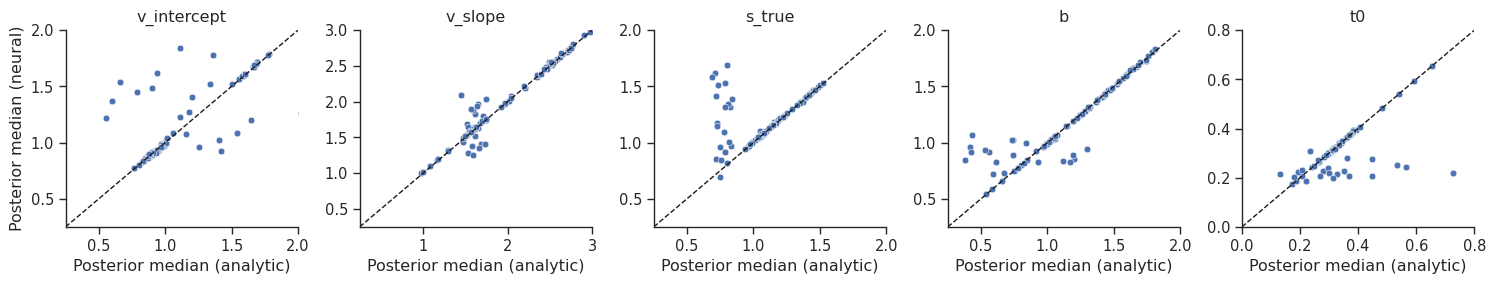

In [316]:
sns.set_theme(context="paper", style="ticks", font_scale=1.2)

g = sns.FacetGrid(df_posterior_median_subject_rdm_join, col="param", sharex=False, sharey=False, margin_titles=True)
g.figure.subplots_adjust(wspace=0, hspace=0)

g.map_dataframe(sns.scatterplot, x="theta_ref", y="theta_approx")

g.set_xlabels(label="Posterior median (analytic)")
g.set_ylabels(label="Posterior median (neural)")

g.set_titles(col_template="{col_name}")

lims_dict = {
    "v_intercept": (0.25, 2.0),
    "v_slope": (0.25, 3.0),
    "s_true": (0.25, 2.0),
    "b": (0.25, 2.0),
    "t0": (0, 0.8),
}

for (col_val), ax in g.axes_dict.items():

    ax.set_xlim(lims_dict[col_val])
    ax.set_ylim(lims_dict[col_val])
    ax.plot(lims_dict[col_val], lims_dict[col_val], 'k--', lw=1)

g.savefig("parameter_recovery/parameter_cross_recovery_hierarchical_subject_rdm.png")

In [317]:
def stack_posterior_pop(dt):
    df = (dt["posterior"].ds[["mu", "sigma"]]
        .to_array(dim="pop_param")                                                                         
        .to_dataset(name="theta")                                                                                                             
    ).merge(dt["constant_data"].ds[["mu", "sigma"]].to_array(dim="pop_param").to_dataset(name="true"))

    df["true"] = xr.where(df["pop_param"] == "mu", np.exp(df.true), df.true)

    return df

In [318]:
posterior_stacked_pop_rdm_approx = stack_posterior_pop(dt_merged_rdm_approx)
posterior_stacked_pop_rdm_ref = stack_posterior_pop(dt_merged_rdm_ref)

In [319]:
df_posterior_median_pop_rdm_approx = calc_posterior_median_df(posterior_stacked_pop_rdm_approx)
df_posterior_median_pop_rdm_ref = calc_posterior_median_df(posterior_stacked_pop_rdm_ref)

df_posterior_median_pop_rdm_join = df_posterior_median_pop_rdm_approx.merge(
    df_posterior_median_pop_rdm_ref,
    on=["pop", "param", "pop_param"],
    suffixes=["_approx", "_ref"]
)

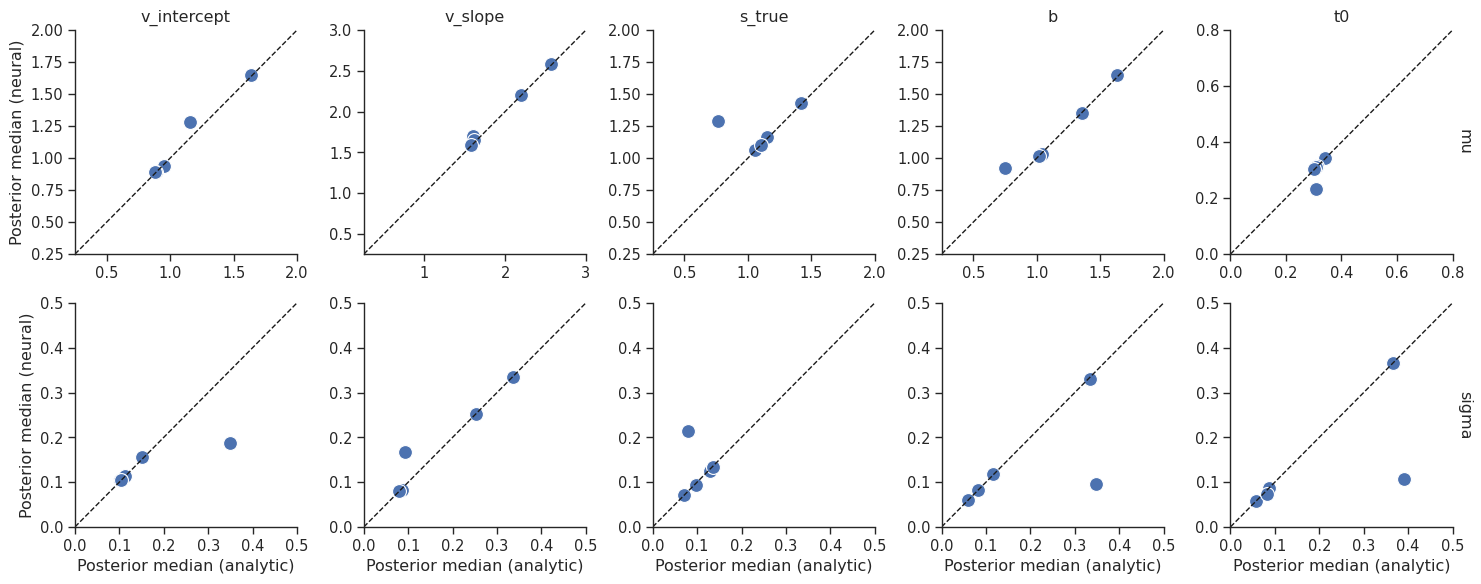

In [320]:
g = sns.FacetGrid(df_posterior_median_pop_rdm_join, row="pop_param", col="param", sharex=False, sharey=False, margin_titles=True)
g.figure.subplots_adjust(wspace=0, hspace=0)

g.map_dataframe(sns.scatterplot, x="theta_ref", y="theta_approx", s=100.0)

g.set_xlabels(label="Posterior median (analytic)")
g.set_ylabels(label="Posterior median (neural)")

g.set_titles(row_template="{row_name}", col_template="{col_name}")

lims_dict = {
    "v_intercept": (0.25, 2.0),
    "v_slope": (0.25, 3.0),
    "s_true": (0.25, 2.0),
    "b": (0.25, 2.0),
    "t0": (0, 0.8),
}

for (row_val, col_val), ax in g.axes_dict.items():
    if row_val == "mu":
        xlim = lims_dict[col_val]
        ylim = lims_dict[col_val]
    else:
        xlim = (0, 0.5)
        ylim = (0, 0.5)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.plot(xlim, ylim, 'k--', lw=1)

g.savefig("parameter_recovery/parameter_cross_recovery_hierarchical_pop_rdm.png")

## CRDM

In [321]:
dt_dict_crdm_approx = {}

for i in range(NUM_POPS):
    dt_path = f"../outputs/crdm/model.num_bins=12/model.num_mid=128/model.sampler.dt=0.0005/optimizer=adam_cosine_decay/train_steps=1000000/hierarchical_recovery_pop{i}_approx.nc"
    dt_dict_crdm_approx[i] = open_datatree(dt_path)


In [322]:
dt_merged_crdm_approx = merge_datatrees(dt_dict_crdm_approx)

In [323]:
(az.rhat(dt_merged_crdm_approx) > 1.1).sum(dim=["subject"])

<xarray.DataTree 'posterior'>
Group: /
    Dimensions:        (pop: 5, param: 7)
    Coordinates:
      * pop            (pop) int64 40B 0 1 2 3 4
      * param          (param) <U13 364B 'v_c_intercept' 'v_c_slope' ... 'b' 't0'
    Data variables:
        mu             (pop, param) bool 35B False False False ... False False False
        sigma          (pop, param) bool 35B False False False ... False False False
        v_c_intercept  (pop) int64 40B 0 20 20 14 0
        v_c_slope      (pop) int64 40B 0 13 19 5 0
        amp            (pop) int64 40B 0 20 20 12 0
        tau            (pop) int64 40B 0 16 0 18 0
        s_true         (pop) int64 40B 0 11 20 4 0
        b              (pop) int64 40B 0 17 20 18 0
        t0             (pop) int64 40B 0 19 17 17 0

In [324]:
posterior_stacked_subject_crdm_approx = stack_posterior_subject(dt_merged_crdm_approx)

In [325]:
df_posterior_median_subject_crdm_approx = calc_posterior_median_df(posterior_stacked_subject_crdm_approx)

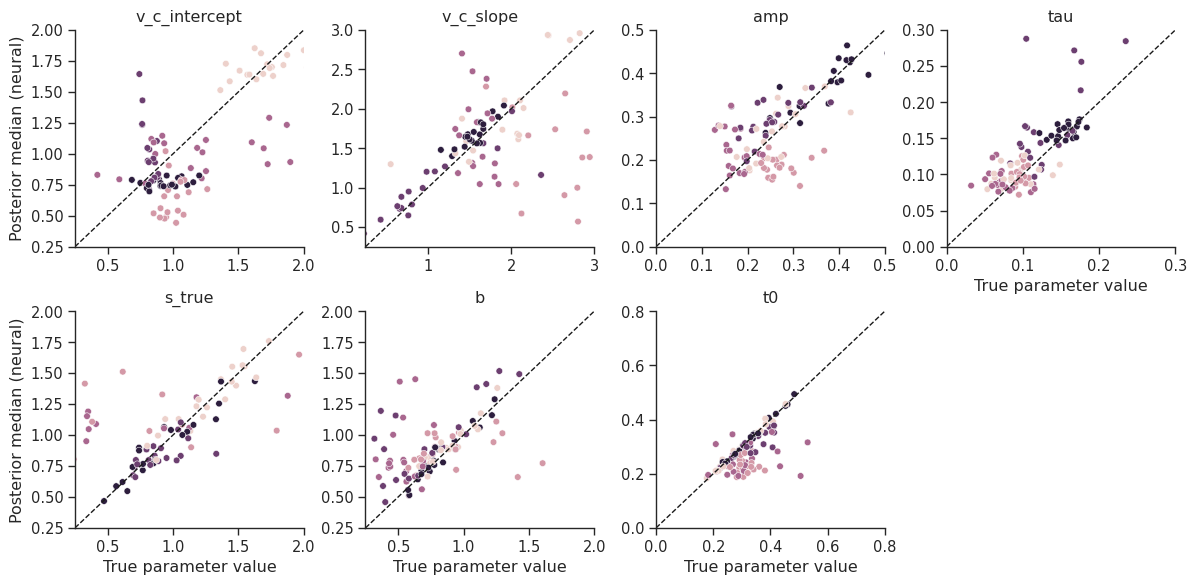

In [326]:
sns.set_theme(context="paper", style="ticks", font_scale=1.2)

g = sns.FacetGrid(df_posterior_median_subject_crdm_approx, col="param", col_wrap=4, sharex=False, sharey=False, margin_titles=True)
g.figure.subplots_adjust(wspace=0, hspace=0)

g.map_dataframe(sns.scatterplot, x="true", y="theta", hue="pop")

g.set_xlabels(label="True parameter value")
g.set_ylabels(label="Posterior median (neural)")

g.set_titles(col_template="{col_name}")

lims_dict = {
    "v_c_intercept": (0.25, 2.0),
    "v_c_slope": (0.25, 3.0),
    "amp": (0, 0.5),
    "tau": (0, 0.3),
    "s_true": (0.25, 2.0),
    "b": (0.25, 2.0),
    "t0": (0, 0.8),
}

for (col_val), ax in g.axes_dict.items():
    ax.set_xlim(lims_dict[col_val])
    ax.set_ylim(lims_dict[col_val])
    ax.plot(lims_dict[col_val], lims_dict[col_val], 'k--', lw=1)

g.savefig("parameter_recovery/parameter_cross_recovery_hierarchical_subject_crdm.png")

In [327]:
posterior_stacked_pop_crdm_approx = stack_posterior_pop(dt_merged_crdm_approx)

In [328]:
df_posterior_median_pop_crdm_approx = calc_posterior_median_df(posterior_stacked_pop_crdm_approx)

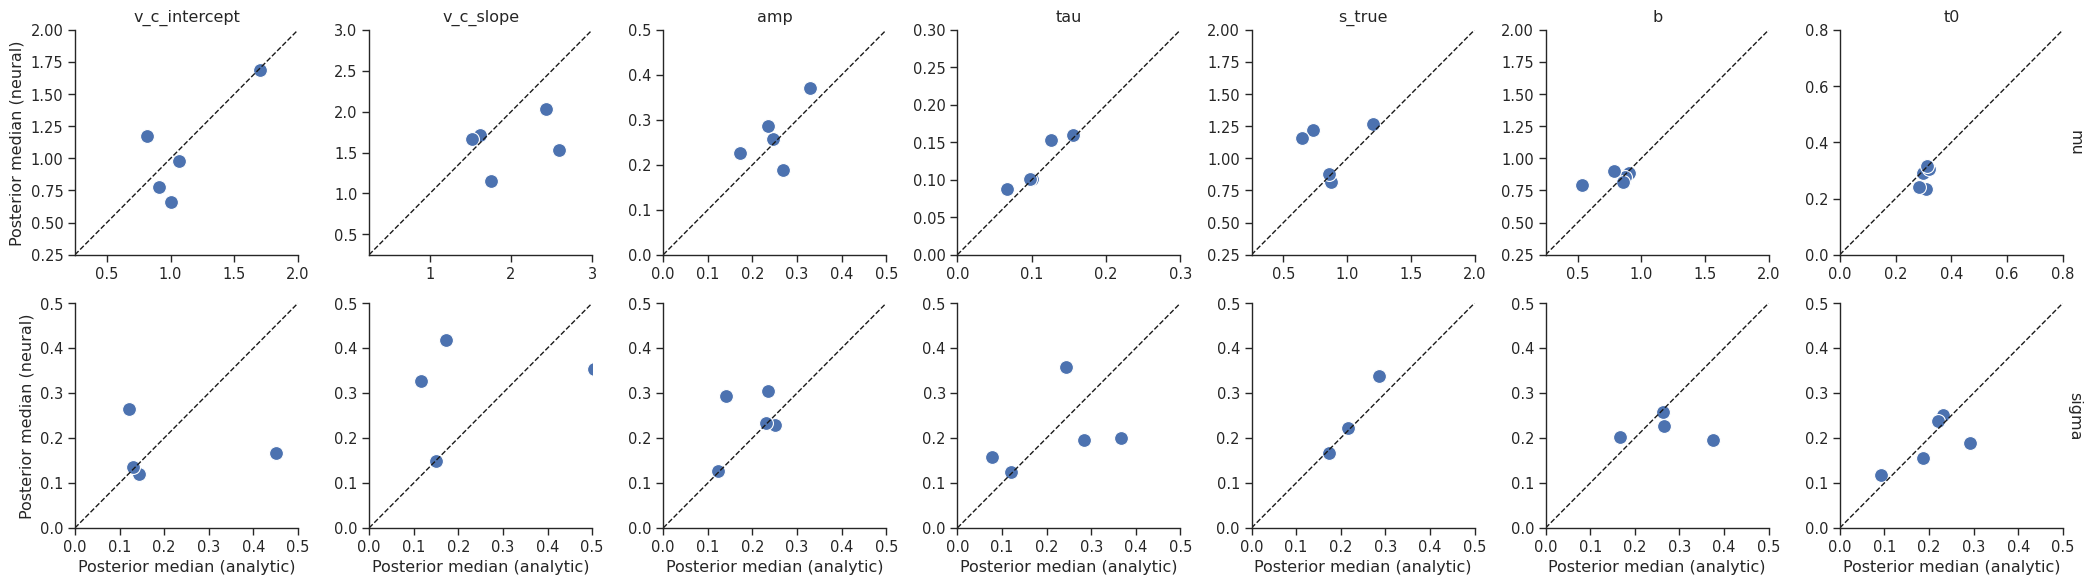

In [329]:
g = sns.FacetGrid(df_posterior_median_pop_crdm_approx, row="pop_param", col="param", sharex=False, sharey=False, margin_titles=True)
g.figure.subplots_adjust(wspace=0, hspace=0)

g.map_dataframe(sns.scatterplot, x="true", y="theta", s=100.0)

g.set_xlabels(label="Posterior median (analytic)")
g.set_ylabels(label="Posterior median (neural)")

g.set_titles(row_template="{row_name}", col_template="{col_name}")

lims_dict = {
    "v_c_intercept": (0.25, 2.0),
    "v_c_slope": (0.25, 3.0),
    "amp": (0, 0.5),
    "tau": (0, 0.3),
    "s_true": (0.25, 2.0),
    "b": (0.25, 2.0),
    "t0": (0, 0.8),
}

for (row_val, col_val), ax in g.axes_dict.items():
    if row_val == "mu":
        xlim = lims_dict[col_val]
        ylim = lims_dict[col_val]
    else:
        xlim = (0, 0.5)
        ylim = (0, 0.5)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.plot(xlim, ylim, 'k--', lw=1)

g.savefig("parameter_recovery/parameter_cross_recovery_hierarchical_pop_crdm.png")